# 02 — Models, tested honestly

## Why the original version of this project was wrong
The first version split the data with `train_test_split`, which **shuffles rows randomly**. Each row's target was the next 21 days' return, and consecutive days share 20 of those 21 days. So the test set contained near-copies of the training rows, and the model effectively saw the answers.

The cell below reproduces the original method on this data and compares it with an honest split (train on the past, test on the future). It takes about a minute.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIRST_TEST_YEAR, REPORTS_DIR
from src.data import load_prices
from src.evaluation import leak_demo, oos_r2
from src.models import run_all, TARGET
from src.features import RANKED

close, volume = load_prices()
leak = leak_demo(close)
leak.round(4).to_frame()

,R2
Random shuffle (original method),0.0123
"Train on past, test on future",-0.0037


## The honest setup: walk-forward
- **Monthly, non-overlapping** targets (next month's return, relative to the average stock)
- **Expanding window, retrained every January** from 2015: each model only trains on months whose outcome was already known
- Hyperparameters (Ridge's penalty, the neural net's stopping point) are chosen on the **most recent 20% of training months**, never on test data

| Model | Idea |
|---|---|
| Momentum (no model) | Baseline: rank stocks by past 12-1 month return |
| Ridge | Linear regression with an L2 penalty |
| GBM | Gradient-boosted trees (shallow, slow learning) |
| Neural net | PyTorch MLP (32-16), dropout, weight decay, early stopping |

This takes a few minutes (12 refits × 4 models).

In [2]:
panel = pd.read_pickle("../data/processed/panel.pkl")
preds, fitted = run_all(panel, FIRST_TEST_YEAR)
preds.to_pickle("../data/processed/predictions.pkl")
preds.describe().T.round(4)

--- Momentum (no model)
2015: trained on 47 months
2016: trained on 59 months
2017: trained on 71 months
2018: trained on 83 months
2019: trained on 95 months
2020: trained on 107 months
2021: trained on 119 months
2022: trained on 131 months
2023: trained on 143 months
2024: trained on 155 months
2025: trained on 167 months
2026: trained on 179 months
--- Ridge
2015: trained on 47 months
2016: trained on 59 months
2017: trained on 71 months
2018: trained on 83 months
2019: trained on 95 months
2020: trained on 107 months
2021: trained on 119 months
2022: trained on 131 months
2023: trained on 143 months
2024: trained on 155 months
2025: trained on 167 months
2026: trained on 179 months
--- GBM
2015: trained on 47 months
2016: trained on 59 months
2017: trained on 71 months
2018: trained on 83 months
2019: trained on 95 months
2020: trained on 107 months
2021: trained on 119 months
2022: trained on 131 months
2023: trained on 143 months
2024: trained on 155 months
2025: trained on 167 

,count,mean,std,min,25%,50%,75%,max
Momentum (no model),7280.0,0.0096,0.2886,-0.4808,-0.2356,0.0096,0.2548,0.5000
Ridge,7280.0,-0.0000,0.0020,-0.0119,-0.0008,-0.0000,0.0008,0.0129
GBM,7280.0,-0.0001,0.0039,-0.0223,-0.0026,-0.0004,0.0014,0.0248
Neural net,7280.0,-0.0006,0.0041,-0.0201,-0.0031,-0.0007,0.0018,0.0242


## Out-of-sample R²
For stock returns, **any positive out-of-sample R² is meaningful**; values around 0.1–1% are typical in the academic literature. Negative means worse than predicting "every stock does average".

The momentum baseline is a ranking, not a return forecast, so R² does not apply to it; it is judged by IC and the long-short test in notebook 03.

In [3]:
test = panel.loc[preds.index]
mask = test[TARGET].notna()
r2 = pd.Series({m: oos_r2(test.loc[mask, TARGET], preds.loc[mask, m]) for m in preds.columns if m != "Momentum (no model)"}, name="OOS R²")
(r2 * 100).round(3).to_frame("OOS R² (%)")

,OOS R² (%)
Ridge,-0.161
GBM,-0.187
Neural net,-0.398


## What did the models learn?
Ridge coefficients and GBM feature importances from the **last** refit.

In [4]:
last = max(fitted["Ridge"])
importance = pd.DataFrame({
    "Ridge coefficient": fitted["Ridge"][last].model_.coef_,
    "GBM importance": fitted["GBM"][last].model_.feature_importances_,
}, index=RANKED)
print("Ridge alpha chosen each year:", {y: m.alpha_ for y, m in fitted["Ridge"].items()})
print("Neural net epochs each year:", {y: m.epochs_ for y, m in fitted["Neural net"].items()})
importance.round(4)

Ridge alpha chosen each year: {2015: 0.1, 2016: 1000, 2017: 1000, 2018: 1000, 2019: 1000, 2020: 1000, 2021: 1000, 2022: 1000, 2023: 0.1, 2024: 1000, 2025: 1, 2026: 1000}
Neural net epochs each year: {2015: 97, 2016: 46, 2017: 80, 2018: 87, 2019: 58, 2020: 39, 2021: 54, 2022: 48, 2023: 38, 2024: 38, 2025: 33, 2026: 81}


,Ridge coefficient,GBM importance
mom_12_1_r,0.0013,0.2254
rev_1m_r,0.0006,0.0747
vol_1m_r,0.0011,0.0602
vol_3m_r,0.0012,0.0902
log_dollar_vol_r,-0.0007,0.0750
amihud_r,0.0004,0.2095
beta_1y_r,0.0032,0.1880
idio_vol_r,0.0012,0.0770


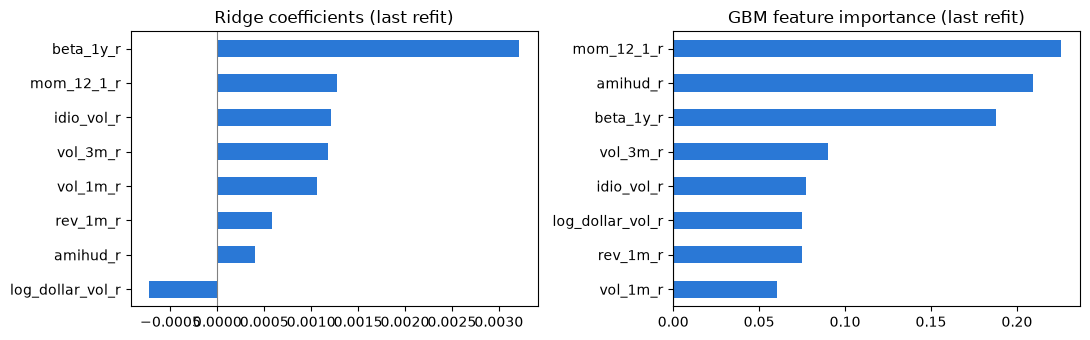

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
importance["Ridge coefficient"].sort_values().plot.barh(ax=axes[0], color="#2a78d6", title="Ridge coefficients (last refit)")
importance["GBM importance"].sort_values().plot.barh(ax=axes[1], color="#2a78d6", title="GBM feature importance (last refit)")
for ax in axes: ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.savefig(REPORTS_DIR / "feature_importance.png", dpi=150); plt.show()

## Key numbers (text summary)

In [6]:
print("The original method vs honest split (R²):")
print(leak.round(4).to_string())
print("\nWalk-forward test period:", preds.index.get_level_values('date').min().date(), "to", preds.index.get_level_values('date').max().date())
print("\nOut-of-sample R² (%):")
print((r2 * 100).round(3).to_string())
print("\nFeature importance (last refit):")
print(importance.round(4).to_string())

The original method vs honest split (R²):
Random shuffle (original method)    0.0123
Train on past, test on future      -0.0037

Walk-forward test period: 2015-01-30 to 2026-08-31

Out-of-sample R² (%):
Ridge        -0.161
GBM          -0.187
Neural net   -0.398

Feature importance (last refit):
                  Ridge coefficient  GBM importance
mom_12_1_r                   0.0013          0.2254
rev_1m_r                     0.0006          0.0747
vol_1m_r                     0.0011          0.0602
vol_3m_r                     0.0012          0.0902
log_dollar_vol_r            -0.0007          0.0750
amihud_r                     0.0004          0.2095
beta_1y_r                    0.0032          0.1880
idio_vol_r                   0.0012          0.0770


## Takeaways

- **The original evaluation was leaking.** Reproduced on this data, the shuffled split gives R² = +0.012 versus −0.004 when training on the past and testing on the future (on the original 5-stock data: +0.13 vs −0.48).
- **Out-of-sample R² is negative for every model** (Ridge −0.16%, GBM −0.19%, neural net −0.40%): none beats predicting the cross-sectional average. The most flexible model does worst, a sign of fitting noise.
- **What the models used (last refit):** Ridge's largest coefficient is market beta, consistent with high-beta stocks outperforming in the 2010–2026 bull market; GBM relies most on momentum (0.23), illiquidity (0.21) and beta (0.19).
- R² is harsh for returns; notebook 03 tests whether the predictions *rank* stocks usefully (IC) and whether that can be traded.